In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import sounddevice as sd
import IPython.display as ipd

# Lista 2 - Visão Computacional


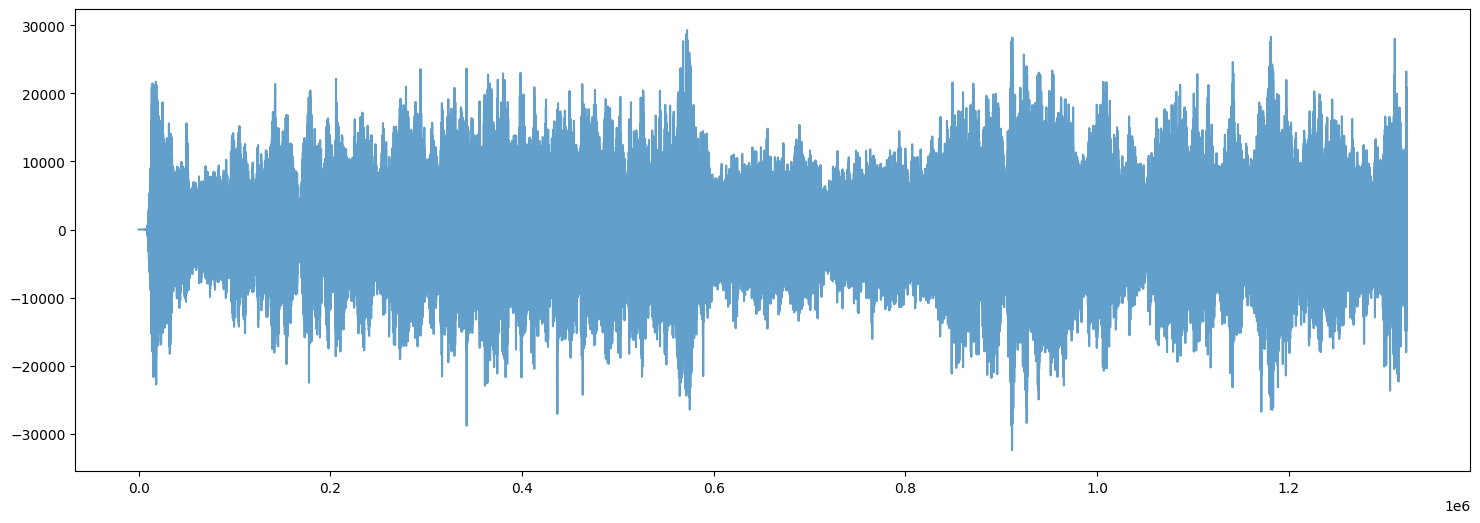

In [60]:
sw_freq, sw_data = wavfile.read("StarWars60.wav")

fig = plt.figure(figsize= (18,6))
plt.plot(sw_data, alpha= 0.7)

A função `wavefile.read` do `scipy` nos retorna a frequência do sinal e um vetor de amplitudes. Sabemos que nossa frequência significa quantas oscilações por segundo nosso sinal faz. Portanto para pegar os primeiros 10 segundos, fazemos:

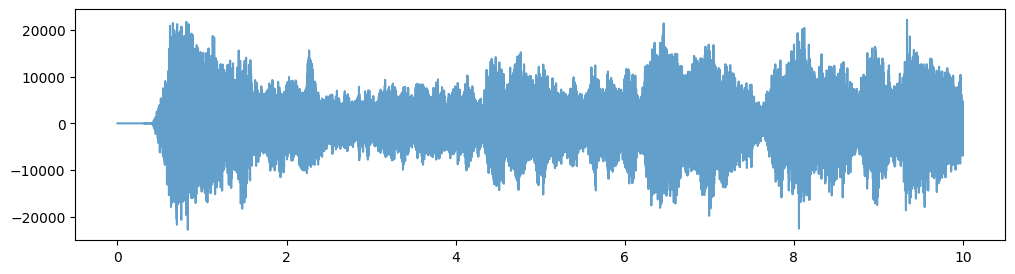

In [61]:
seg_10 = sw_freq * 10
sw_10seg = sw_data[0:seg_10]

fig = plt.figure(figsize=(12,3))
plt.plot(np.linspace(0, 10, seg_10), sw_10seg, alpha= 0.7)

In [67]:
ipd.display(ipd.Audio(sw_10seg, rate= sw_freq))

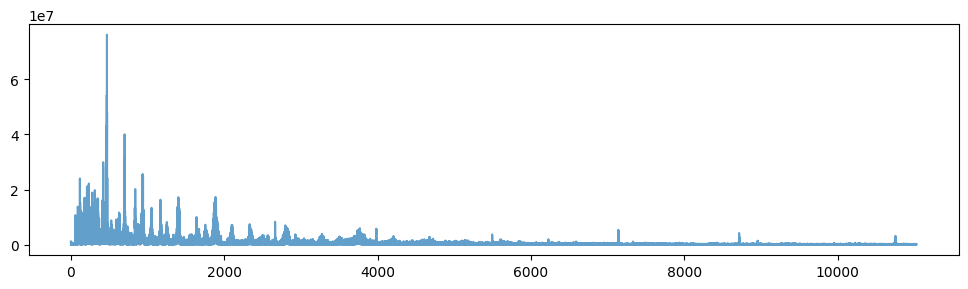

In [63]:
def calcular_coeficientes(sinal, sinal_freq):
    coef_magnitude = np.abs(np.fft.fft(sinal))
    frequencias = np.fft.fftfreq(len(sinal), d=1/sinal_freq)
    metade = len(sw_10seg)//2

    return coef_magnitude[:metade], frequencias[:metade]

sw_coef, sw_coef_freq = calcular_coeficientes(sw_10seg, sw_freq)

fig = plt.figure(figsize= (12,3))
plt.plot(sw_coef_freq, sw_coef, alpha= 0.7)

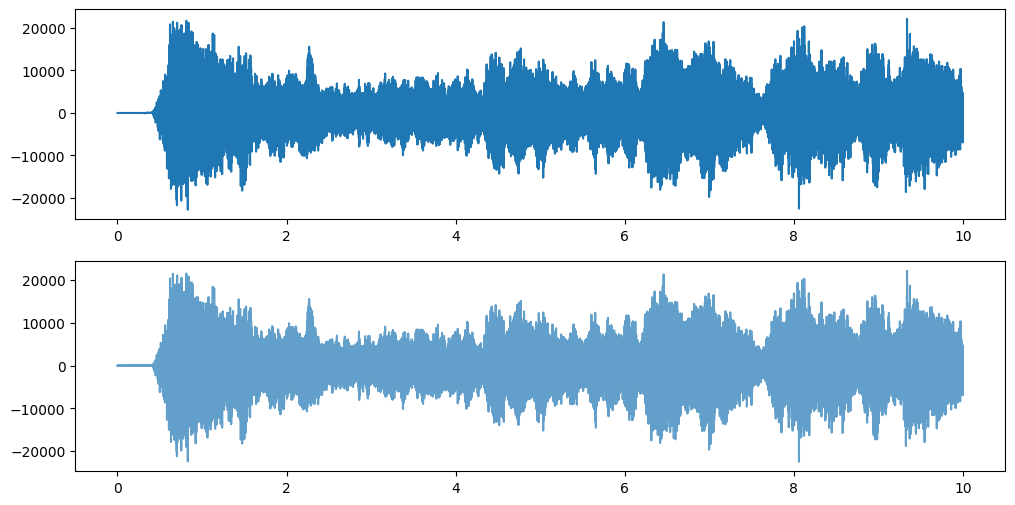

In [87]:
def comprimir(sinal, porcentagem):
    tam = len(sinal)
    tam_comp = int((len(sinal) * porcentagem)//2)

    coeficientes = np.fft.fft(sinal)

    coef_comprimido = np.zeros_like(coeficientes)
    coef_comprimido[:tam_comp] = coeficientes[:tam_comp]
    coef_comprimido[tam-tam_comp:] = coeficientes[tam-tam_comp:]

    sinal_reconstruido = np.fft.ifft(coef_comprimido).real

    return sinal_reconstruido, coef_comprimido
    
sinal_reconstruido, coef_comprimido = comprimir(sw_10seg, 0.8)

eixo_x = np.linspace(0, 10, len(sw_10seg))
fig, axes = plt.subplots(2, 1, figsize= (12,6))
axes[0].plot(eixo_x, sw_10seg)
axes[1].plot(eixo_x, sinal_reconstruido, alpha= 0.7)